# Entrance People Counting

This notebook counts people crossing the entrance in `resources/data/entrance.mov`.

Design choices made for this video:

- Use a tracking-by-detection pipeline: YOLO person detection plus ByteTrack tracking through Ultralytics.
- Count crossing events on a doorway threshold line, not people standing in the scene.
- Use the bottom-center of each person box as the tracked point because it best approximates the person's contact point with the floor.
- Save generated artifacts under `output/` when the notebook is executed.

Run the cells from top to bottom. If the first run installs `ultralytics`, restart the kernel only if the import still fails afterward.

In [1]:
# Runtime setup. This keeps the project implementation in this notebook only.
import importlib.util
import subprocess
import sys
from pathlib import Path

REQUIRED_PACKAGES = {
    "cv2": "opencv-python",
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "torch": "torch",
    "ultralytics": "ultralytics",
    "lap": "lap",
}

missing = [pip_name for import_name, pip_name in REQUIRED_PACKAGES.items() if importlib.util.find_spec(import_name) is None]
if missing:
    print("Installing missing packages:", ", ".join(missing))
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
else:
    print("All required packages are available.")

All required packages are available.


In [2]:
from __future__ import annotations

import math
import os
import time
from collections import defaultdict, deque
from dataclasses import dataclass, field
from pathlib import Path
from typing import Deque, Dict, Iterable, List, Optional, Tuple

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Video, display
from ultralytics import YOLO

PROJECT_ROOT = Path.cwd()
VIDEO_PATH = PROJECT_ROOT / "resources" / "data" / "entrance.mov"
OUTPUT_DIR = PROJECT_ROOT / "output"
MODEL_DIR = OUTPUT_DIR / "models"

OUTPUT_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

def display_path(path: Path) -> str:
    try:
        return str(path.relative_to(PROJECT_ROOT))
    except ValueError:
        return str(path)

assert VIDEO_PATH.exists(), f"Video not found: {VIDEO_PATH}"
print(f"Using video: {VIDEO_PATH}")

Using video: /Users/temicide/Documents/Connected_Tech/resources/data/entrance.mov


In [3]:
# Configuration chosen for this entrance video.
# Edit COUNTING_LINE if the preview below shows the threshold in the wrong place.

MODEL_NAME = "yolov8n.pt"  # Small and fast COCO person detector. Downloaded to output/models/ if needed.
PERSON_CLASS_ID = 0
CONFIDENCE = 0.22
IOU_THRESHOLD = 0.50
IMAGE_SIZE = 960
PROCESS_EVERY_N_FRAMES = 1
MAX_FRAMES = None  # Use an integer for a quick test run, e.g. 300.

# Doorway floor threshold, selected from sampled frames of this 1920x1080 video.
# The line is intentionally limited to the visible entrance width to avoid counting people at the table.
COUNTING_LINE = ((330, 785), (870, 812))

# Direction convention for this camera:
# positive crossing follows the line normal, which is generally from the doorway/interior toward the foreground/outside.
POSITIVE_DIRECTION_LABEL = "out"
NEGATIVE_DIRECTION_LABEL = "in"
INVERT_DIRECTIONS = False

# Stabilization heuristics.
MIN_SIDE_ABS = 8.0              # Ignore tiny side changes caused by box jitter at the line.
MIN_TRACK_AGE_FRAMES = 3        # Require a short track history before counting a normal crossing.
COUNT_COOLDOWN_FRAMES = 18      # Suppress repeated back-and-forth jitter near the line.
MIN_DISPLACEMENT_PX = 18.0      # Require enough motion between points to count.
LATE_INIT_BUFFER_PX = 45.0      # Auxiliary gate zone for tracks that first appear on the threshold.
LATE_INIT_MAX_AGE_FRAMES = 18
DRAW_TRACK_HISTORY = True

# Output artifacts generated when the tracking cell runs.
ROI_PREVIEW_PATH = OUTPUT_DIR / "entrance_roi_preview.jpg"
ANNOTATED_VIDEO_PATH = OUTPUT_DIR / "entrance_people_count_annotated.mp4"
EVENTS_CSV_PATH = OUTPUT_DIR / "entrance_people_count_events.csv"
SUMMARY_CSV_PATH = OUTPUT_DIR / "entrance_people_count_summary.csv"

print("Counting line:", COUNTING_LINE)

Counting line: ((330, 785), (870, 812))


In [4]:
def read_video_metadata(video_path: Path) -> dict:
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video: {video_path}")
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = float(cap.get(cv2.CAP_PROP_FPS) or 30.0)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration = frame_count / fps if fps else None
    cap.release()
    return {
        "width": width,
        "height": height,
        "fps": fps,
        "frame_count": frame_count,
        "duration_seconds": duration,
    }

metadata = read_video_metadata(VIDEO_PATH)
metadata

{'width': 1920,
 'height': 1080,
 'fps': 29.882504238031217,
 'frame_count': 2556,
 'duration_seconds': 85.535}

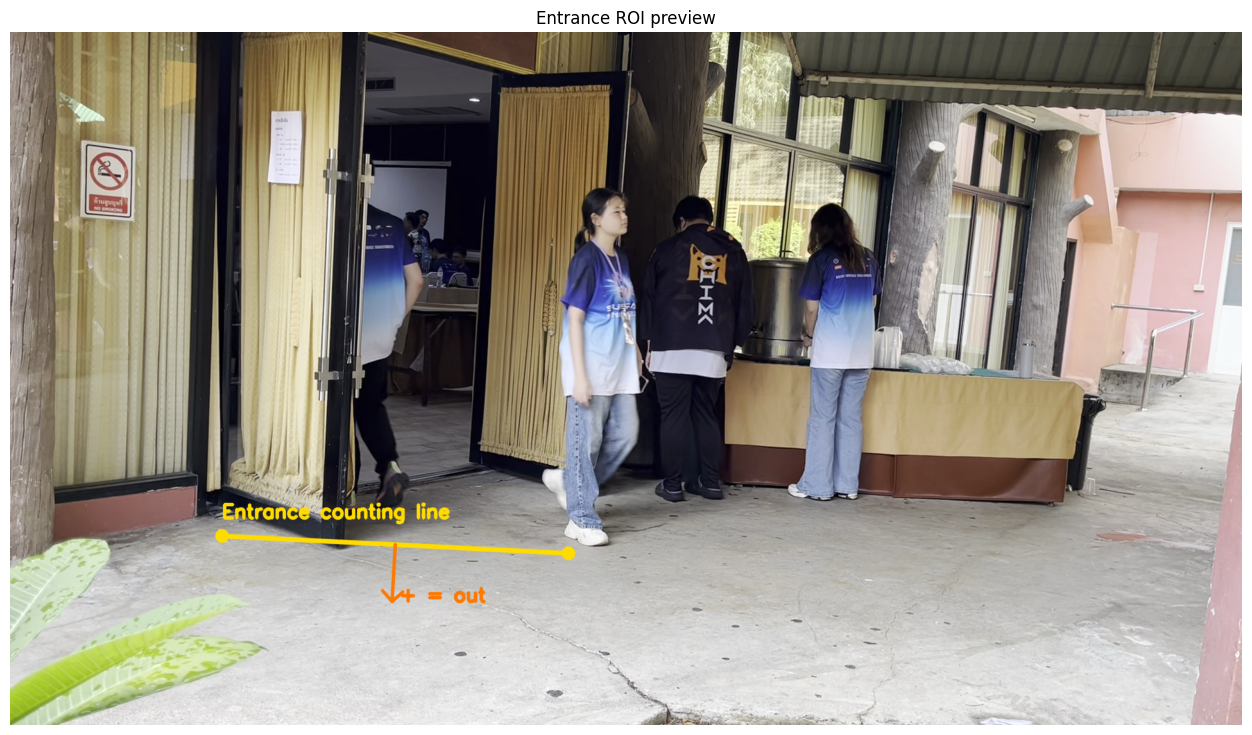

Saved ROI preview to: /Users/temicide/Documents/Connected_Tech/output/entrance_roi_preview.jpg


In [5]:
def frame_at(video_path: Path, second: float) -> np.ndarray:
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video: {video_path}")
    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(second * fps))
    ok, frame = cap.read()
    cap.release()
    if not ok:
        raise RuntimeError(f"Could not read frame at {second:.2f}s")
    return frame

def draw_counting_line(frame: np.ndarray, line: Tuple[Tuple[int, int], Tuple[int, int]], thickness: int = 5) -> np.ndarray:
    out = frame.copy()
    p1, p2 = line
    cv2.line(out, p1, p2, (0, 220, 255), thickness, cv2.LINE_AA)
    cv2.circle(out, p1, 10, (0, 220, 255), -1, cv2.LINE_AA)
    cv2.circle(out, p2, 10, (0, 220, 255), -1, cv2.LINE_AA)

    midpoint = ((p1[0] + p2[0]) // 2, (p1[1] + p2[1]) // 2)
    dx, dy = p2[0] - p1[0], p2[1] - p1[1]
    normal = np.array([-dy, dx], dtype=float)
    normal /= max(float(np.linalg.norm(normal)), 1.0)
    arrow_end = (int(midpoint[0] + normal[0] * 90), int(midpoint[1] + normal[1] * 90))
    cv2.arrowedLine(out, midpoint, arrow_end, (0, 120, 255), 4, cv2.LINE_AA, tipLength=0.25)
    cv2.putText(out, f"+ = {POSITIVE_DIRECTION_LABEL}", (arrow_end[0] + 12, arrow_end[1]),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 120, 255), 3, cv2.LINE_AA)
    cv2.putText(out, "Entrance counting line", (p1[0], max(45, p1[1] - 28)),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 220, 255), 3, cv2.LINE_AA)
    return out

preview_frame = frame_at(VIDEO_PATH, 25)
preview = draw_counting_line(preview_frame, COUNTING_LINE)
cv2.imwrite(str(ROI_PREVIEW_PATH), preview)

plt.figure(figsize=(16, 9))
plt.imshow(cv2.cvtColor(preview, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Entrance ROI preview")
plt.show()
print(f"Saved ROI preview to: {ROI_PREVIEW_PATH}")

In [6]:
def choose_device() -> str | int:
    if torch.cuda.is_available():
        return 0
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return "mps"
    return "cpu"

def load_yolo_model(model_name: str = MODEL_NAME) -> YOLO:
    """Load model while keeping downloaded weights under output/models when possible."""
    model_path = MODEL_DIR / model_name
    if model_path.exists():
        return YOLO(str(model_path))

    old_cwd = Path.cwd()
    try:
        os.chdir(MODEL_DIR)
        model = YOLO(model_name)
    finally:
        os.chdir(old_cwd)

    if not model_path.exists():
        print("Model was loaded, but the weight file location is managed by Ultralytics cache.")
    return model

device = choose_device()
model = load_yolo_model(MODEL_NAME)
print(f"Loaded {MODEL_NAME} on device: {device}")

Loaded yolov8n.pt on device: mps


In [7]:
Point = Tuple[float, float]
Line = Tuple[Tuple[int, int], Tuple[int, int]]

@dataclass
class TrackState:
    points: Deque[Point] = field(default_factory=lambda: deque(maxlen=32))
    sides: Deque[float] = field(default_factory=lambda: deque(maxlen=32))
    first_frame: Optional[int] = None
    first_point: Optional[Point] = None
    first_side: Optional[float] = None
    last_count_frame: int = -10_000
    last_direction: Optional[str] = None


def bottom_center_xy(xyxy: Iterable[float]) -> Point:
    x1, y1, x2, y2 = map(float, xyxy)
    return ((x1 + x2) / 2.0, y2)


def signed_line_side(point: Point, line: Line) -> float:
    (x1, y1), (x2, y2) = line
    x, y = point
    return (x2 - x1) * (y - y1) - (y2 - y1) * (x - x1)


def normalized_line_side(point: Point, line: Line) -> float:
    (x1, y1), (x2, y2) = line
    length = math.hypot(x2 - x1, y2 - y1)
    return signed_line_side(point, line) / max(length, 1.0)


def projection_t(point: Point, line: Line) -> float:
    (x1, y1), (x2, y2) = line
    px, py = point
    vx, vy = x2 - x1, y2 - y1
    denom = vx * vx + vy * vy
    if denom <= 0:
        return 0.0
    return ((px - x1) * vx + (py - y1) * vy) / denom


def orientation(a: Point, b: Point, c: Point) -> float:
    return (b[0] - a[0]) * (c[1] - a[1]) - (b[1] - a[1]) * (c[0] - a[0])


def segments_intersect(a: Point, b: Point, c: Point, d: Point) -> bool:
    o1 = orientation(a, b, c)
    o2 = orientation(a, b, d)
    o3 = orientation(c, d, a)
    o4 = orientation(c, d, b)
    return (o1 * o2 < 0) and (o3 * o4 < 0)


def movement_direction(prev_point: Point, curr_point: Point, line: Line) -> str:
    (x1, y1), (x2, y2) = line
    line_dx, line_dy = x2 - x1, y2 - y1
    normal = np.array([-line_dy, line_dx], dtype=float)
    motion = np.array([curr_point[0] - prev_point[0], curr_point[1] - prev_point[1]], dtype=float)
    dot = float(motion @ normal)
    positive = dot >= 0
    if INVERT_DIRECTIONS:
        positive = not positive
    return POSITIVE_DIRECTION_LABEL if positive else NEGATIVE_DIRECTION_LABEL


def eligible_crossing(prev_point: Point, curr_point: Point, prev_side: float, curr_side: float, line: Line) -> bool:
    if abs(prev_side) < MIN_SIDE_ABS and abs(curr_side) < MIN_SIDE_ABS:
        return False
    if prev_side == 0 or curr_side == 0:
        changed_side = True
    else:
        changed_side = (prev_side > 0) != (curr_side > 0)
    if not changed_side:
        return False

    displacement = math.hypot(curr_point[0] - prev_point[0], curr_point[1] - prev_point[1])
    if displacement < MIN_DISPLACEMENT_PX:
        return False

    if segments_intersect(prev_point, curr_point, line[0], line[1]):
        return True

    # Allow small tracker jumps as long as the crossing happened within the finite line extent.
    t0 = projection_t(prev_point, line)
    t1 = projection_t(curr_point, line)
    return (max(t0, t1) >= -0.05) and (min(t0, t1) <= 1.05)


def maybe_late_init_crossing(state: TrackState, curr_point: Point, curr_side: float, frame_idx: int, line: Line) -> Optional[str]:
    if state.first_frame is None or state.first_point is None or state.first_side is None:
        return None
    age = frame_idx - state.first_frame
    if age > LATE_INIT_MAX_AGE_FRAMES:
        return None
    if abs(state.first_side) > LATE_INIT_BUFFER_PX:
        return None
    if abs(curr_side) <= LATE_INIT_BUFFER_PX:
        return None
    displacement = math.hypot(curr_point[0] - state.first_point[0], curr_point[1] - state.first_point[1])
    if displacement < max(MIN_DISPLACEMENT_PX * 2.0, 42.0):
        return None
    t = projection_t(state.first_point, line)
    if not (-0.08 <= t <= 1.08):
        return None
    return movement_direction(state.first_point, curr_point, line)


def count_event_allowed(state: TrackState, frame_idx: int, direction: str) -> bool:
    if frame_idx - state.last_count_frame < COUNT_COOLDOWN_FRAMES:
        return False
    return True

print("Geometry helpers ready.")

Geometry helpers ready.


In [8]:
def draw_annotations(
    frame: np.ndarray,
    boxes_xyxy: np.ndarray,
    track_ids: np.ndarray,
    states: Dict[int, TrackState],
    counts: Dict[str, int],
    frame_idx: int,
    fps: float,
    line: Line = COUNTING_LINE,
) -> np.ndarray:
    annotated = draw_counting_line(frame, line, thickness=4)

    for xyxy, track_id in zip(boxes_xyxy, track_ids):
        x1, y1, x2, y2 = map(int, xyxy)
        tid = int(track_id)
        point = bottom_center_xy(xyxy)
        color = (80, 220, 80)
        cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2, cv2.LINE_AA)
        cv2.circle(annotated, (int(point[0]), int(point[1])), 5, (0, 255, 255), -1, cv2.LINE_AA)
        cv2.putText(annotated, f"ID {tid}", (x1, max(24, y1 - 8)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.65, color, 2, cv2.LINE_AA)

        if DRAW_TRACK_HISTORY and tid in states:
            pts = list(states[tid].points)
            for a, b in zip(pts[-16:-1], pts[-15:]):
                cv2.line(annotated, (int(a[0]), int(a[1])), (int(b[0]), int(b[1])), (80, 180, 255), 2, cv2.LINE_AA)

    panel_x, panel_y = 24, 28
    panel_w, panel_h = 390, 150
    overlay = annotated.copy()
    cv2.rectangle(overlay, (panel_x, panel_y), (panel_x + panel_w, panel_y + panel_h), (0, 0, 0), -1)
    annotated = cv2.addWeighted(overlay, 0.45, annotated, 0.55, 0)

    total = counts.get(POSITIVE_DIRECTION_LABEL, 0) + counts.get(NEGATIVE_DIRECTION_LABEL, 0)
    seconds = frame_idx / max(fps, 1e-6)
    lines = [
        f"People Count: {total}",
        f"{NEGATIVE_DIRECTION_LABEL}: {counts.get(NEGATIVE_DIRECTION_LABEL, 0)}   {POSITIVE_DIRECTION_LABEL}: {counts.get(POSITIVE_DIRECTION_LABEL, 0)}",
        f"Frame: {frame_idx}   Time: {seconds:0.1f}s",
    ]
    for i, text in enumerate(lines):
        cv2.putText(annotated, text, (panel_x + 18, panel_y + 42 + i * 42),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 255, 255), 3, cv2.LINE_AA)
    return annotated

print("Annotation helper ready.")

Annotation helper ready.


In [9]:
def extract_track_outputs(result) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    if result.boxes is None or result.boxes.id is None:
        return np.empty((0, 4), dtype=float), np.empty((0,), dtype=int), np.empty((0,), dtype=float)
    boxes = result.boxes.xyxy.detach().cpu().numpy()
    ids = result.boxes.id.detach().cpu().numpy().astype(int)
    confs = result.boxes.conf.detach().cpu().numpy() if result.boxes.conf is not None else np.ones(len(ids), dtype=float)
    return boxes, ids, confs


def run_people_counting() -> Tuple[pd.DataFrame, pd.DataFrame]:
    cap = cv2.VideoCapture(str(VIDEO_PATH))
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video: {VIDEO_PATH}")

    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = float(cap.get(cv2.CAP_PROP_FPS) or 30.0)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    output_fps = fps / max(PROCESS_EVERY_N_FRAMES, 1)

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(str(ANNOTATED_VIDEO_PATH), fourcc, output_fps, (width, height))
    if not writer.isOpened():
        cap.release()
        raise RuntimeError(f"Could not create output video: {ANNOTATED_VIDEO_PATH}")

    states: Dict[int, TrackState] = defaultdict(TrackState)
    counts = {NEGATIVE_DIRECTION_LABEL: 0, POSITIVE_DIRECTION_LABEL: 0}
    events: List[dict] = []
    processed = 0
    frame_idx = -1
    start = time.time()

    while True:
        ok, frame = cap.read()
        if not ok:
            break
        frame_idx += 1
        if MAX_FRAMES is not None and frame_idx >= MAX_FRAMES:
            break
        if frame_idx % PROCESS_EVERY_N_FRAMES != 0:
            continue

        results = model.track(
            frame,
            persist=True,
            classes=[PERSON_CLASS_ID],
            conf=CONFIDENCE,
            iou=IOU_THRESHOLD,
            imgsz=IMAGE_SIZE,
            tracker="bytetrack.yaml",
            device=device,
            verbose=False,
        )
        result = results[0]
        boxes_xyxy, track_ids, confs = extract_track_outputs(result)

        for xyxy, track_id, conf in zip(boxes_xyxy, track_ids, confs):
            tid = int(track_id)
            state = states[tid]
            point = bottom_center_xy(xyxy)
            side = normalized_line_side(point, COUNTING_LINE)

            if state.first_frame is None:
                state.first_frame = frame_idx
                state.first_point = point
                state.first_side = side

            counted_direction = None
            counted_by = None

            if len(state.points) >= 1:
                prev_point = state.points[-1]
                prev_side = state.sides[-1]
                track_age = frame_idx - (state.first_frame if state.first_frame is not None else frame_idx)
                if track_age >= MIN_TRACK_AGE_FRAMES and eligible_crossing(prev_point, point, prev_side, side, COUNTING_LINE):
                    direction = movement_direction(prev_point, point, COUNTING_LINE)
                    if count_event_allowed(state, frame_idx, direction):
                        counted_direction = direction
                        counted_by = "line_crossing"

            if counted_direction is None:
                direction = maybe_late_init_crossing(state, point, side, frame_idx, COUNTING_LINE)
                if direction is not None and count_event_allowed(state, frame_idx, direction):
                    counted_direction = direction
                    counted_by = "late_init_buffer"

            if counted_direction is not None:
                counts[counted_direction] = counts.get(counted_direction, 0) + 1
                state.last_count_frame = frame_idx
                state.last_direction = counted_direction
                events.append({
                    "event_index": len(events) + 1,
                    "frame": frame_idx,
                    "time_seconds": frame_idx / max(fps, 1e-6),
                    "track_id": tid,
                    "direction": counted_direction,
                    "counted_by": counted_by,
                    "bottom_center_x": point[0],
                    "bottom_center_y": point[1],
                    "confidence": float(conf),
                    "in_count": counts.get(NEGATIVE_DIRECTION_LABEL, 0),
                    "out_count": counts.get(POSITIVE_DIRECTION_LABEL, 0),
                    "total_count": counts.get(NEGATIVE_DIRECTION_LABEL, 0) + counts.get(POSITIVE_DIRECTION_LABEL, 0),
                })

            state.points.append(point)
            state.sides.append(side)

        annotated = draw_annotations(frame, boxes_xyxy, track_ids, states, counts, frame_idx, fps, COUNTING_LINE)
        writer.write(annotated)
        processed += 1

        if processed % 100 == 0:
            elapsed = max(time.time() - start, 1e-6)
            print(f"Processed {processed} frames at {processed / elapsed:0.2f} FPS | total={counts[NEGATIVE_DIRECTION_LABEL] + counts[POSITIVE_DIRECTION_LABEL]}")

    cap.release()
    writer.release()

    events_df = pd.DataFrame(events)
    if events_df.empty:
        events_df = pd.DataFrame(columns=[
            "event_index", "frame", "time_seconds", "track_id", "direction", "counted_by",
            "bottom_center_x", "bottom_center_y", "confidence", "in_count", "out_count", "total_count"
        ])

    summary_df = pd.DataFrame([{
        "video": str(VIDEO_PATH.relative_to(PROJECT_ROOT)),
        "width": width,
        "height": height,
        "fps": fps,
        "frames_in_video": frame_count,
        "frames_processed": processed,
        "duration_seconds": frame_count / max(fps, 1e-6),
        "counting_line": str(COUNTING_LINE),
        "in_count": counts.get(NEGATIVE_DIRECTION_LABEL, 0),
        "out_count": counts.get(POSITIVE_DIRECTION_LABEL, 0),
        "total_count": counts.get(NEGATIVE_DIRECTION_LABEL, 0) + counts.get(POSITIVE_DIRECTION_LABEL, 0),
        "model": MODEL_NAME,
        "confidence": CONFIDENCE,
        "image_size": IMAGE_SIZE,
        "process_every_n_frames": PROCESS_EVERY_N_FRAMES,
        "annotated_video": display_path(ANNOTATED_VIDEO_PATH),
        "events_csv": display_path(EVENTS_CSV_PATH),
    }])

    events_df.to_csv(EVENTS_CSV_PATH, index=False)
    summary_df.to_csv(SUMMARY_CSV_PATH, index=False)

    elapsed = max(time.time() - start, 1e-6)
    print(f"Done. Processed {processed} frames in {elapsed:0.1f}s ({processed / elapsed:0.2f} FPS).")
    print(f"Saved events: {EVENTS_CSV_PATH}")
    print(f"Saved summary: {SUMMARY_CSV_PATH}")
    print(f"Saved annotated video: {ANNOTATED_VIDEO_PATH}")
    return events_df, summary_df

# Run the full count. Set MAX_FRAMES above for a shorter test run.
events_df, summary_df = run_people_counting()
summary_df

Processed 100 frames at 23.56 FPS | total=1


Processed 200 frames at 27.14 FPS | total=2


Processed 300 frames at 28.87 FPS | total=4


Processed 400 frames at 29.84 FPS | total=6


Processed 500 frames at 30.26 FPS | total=6


...

Processed 2300 frames at 26.61 FPS | total=25


Processed 2400 frames at 26.37 FPS | total=25


Processed 2500 frames at 26.24 FPS | total=25


Done. Processed 2548 frames in 97.3s (26.19 FPS).
Saved events: /Users/temicide/Documents/Connected_Tech/output/entrance_people_count_events.csv
Saved summary: /Users/temicide/Documents/Connected_Tech/output/entrance_people_count_summary.csv
Saved annotated video: /Users/temicide/Documents/Connected_Tech/output/entrance_people_count_annotated.mp4


,video,width,height,fps,frames_in_video,frames_processed,duration_seconds,counting_line,in_count,out_count,total_count,model,confidence,image_size,process_every_n_frames,annotated_video,events_csv
0,resources/data/entrance.mov,1920,1080,29.882504,2556,2548,85.535,"((330, 785), (870, 812))",7,18,25,yolov8n.pt,0.22,960,1,output/entrance_people_count_annotated.mp4,output/entrance_people_count_events.csv


In [10]:
events_df.tail(20)

,event_index,frame,time_seconds,track_id,direction,counted_by,bottom_center_x,bottom_center_y,confidence,in_count,out_count,total_count
5,6,391,13.084579,113,out,line_crossing,756.918365,817.248535,0.823397,0,6,6
6,7,529,17.702666,124,out,line_crossing,951.662323,848.069336,0.763971,0,7,7
7,8,730,24.429010,199,in,line_crossing,654.080566,790.192200,0.893575,1,7,8
8,9,1177,39.387596,403,out,line_crossing,595.819290,809.544556,0.670133,1,8,9
9,10,1181,39.521453,388,out,line_crossing,853.026703,822.417908,0.735450,1,9,10
10,11,1277,42.734036,421,out,line_crossing,860.167480,860.612793,0.550924,1,10,11
11,12,1278,42.767500,435,out,line_crossing,691.044739,807.411133,0.666902,1,11,12
12,13,1288,43.102144,445,in,late_init_buffer,595.343262,728.507202,0.676143,2,11,13
13,14,1364,45.645438,420,out,line_crossing,877.416290,814.935608,0.487114,2,12,14
14,15,1402,46.917085,500,in,line_crossing,641.506287,687.468628,0.730108,3,12,15


In [11]:
print("Summary")
display(summary_df)

if ANNOTATED_VIDEO_PATH.exists():
    display(Video(str(ANNOTATED_VIDEO_PATH), embed=False, width=960))

Summary


,video,width,height,fps,frames_in_video,frames_processed,duration_seconds,counting_line,in_count,out_count,total_count,model,confidence,image_size,process_every_n_frames,annotated_video,events_csv
0,resources/data/entrance.mov,1920,1080,29.882504,2556,2548,85.535,"((330, 785), (870, 812))",7,18,25,yolov8n.pt,0.22,960,1,output/entrance_people_count_annotated.mp4,output/entrance_people_count_events.csv


## Notes for Interpreting Results

The total is a crossing-event count, not a frame-level occupancy count. A person standing near the doorway is not counted until their tracked bottom-center crosses the entrance threshold line. The `in` and `out` labels are based on the selected line normal and can be swapped by setting `INVERT_DIRECTIONS = True` if visual review shows the direction convention is reversed.